# Practice 3: Sentiment Analysis with Hugging Face Transformers

This notebook presents an end-to-end binary sentiment-classification workflow on the Rotten Tomatoes dataset. Core processing stays in `processing_own_phase/*.py`; the notebook calls those modules and presents verified results.

## Phase 0 - Problem Definition

### Objective

Build and verify a DistilBERT classifier that maps an English movie review to `NEGATIVE` or `POSITIVE`.

| Item | Definition |
|---|---|
| Input | English movie-review text |
| Output | `0 = NEGATIVE`, `1 = POSITIVE` |
| Dataset | Rotten Tomatoes: 8,530 Train / 1,066 Validation / 1,066 Test |
| Model | `distilbert/distilbert-base-uncased` |
| Metrics | Loss, Accuracy, Precision, Recall and F1 |
| Selection rule | Lowest Validation loss; Test is used once after checkpoint selection |

### Success Criteria

- Dataset, labels, tokenization and preprocessing pass sanity checks.
- Fine-tuning uses Train; checkpoint selection uses Validation only.
- The locked checkpoint is evaluated once on Test.
- Saved model and tokenizer reload with equivalent predictions.

### Workflow

![Practice 3 workflow](../docs/result/phase_00_pipeline_uml.png)

The workflow keeps model selection on Validation and uses Test only for the locked model's final evaluation.

## Phase 1 Environment & Reproducibility

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added: {project_root}") 

Project root added: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3


In [2]:
# Phase 1: Environment & Reproducibility
from processing_own_phase.phase_01_environment import (
    set_seed,
    print_environment_info,
    save_environment_report,
)

# Set seed (must be done before running anything else)
set_seed(42)

# Print full report and save JSON file
info = print_environment_info()
filepath = save_environment_report(info)

# Quick summary
print(f"\nReport saved: {filepath}")
print(f"Device: {info['device']}")
print(f"Seed: {info['seed']}")


ENVIRONMENT INFORMATION
Timestamp: 2026-08-15T16:18:25.629598
Python Version: 3.11.14
Device: mps
Global Seed: 42

--- Package Versions ---
[OK     ] transformers    installed: 5.14.1       required: 5.14.1
[OK     ] datasets        installed: 5.0.1        required: 5.0.1
[OK     ] evaluate        installed: 0.4.6        required: 0.4.6
[OK     ] accelerate      installed: 1.14.0       required: 1.14.0
[OK     ] torch           installed: 2.13.0       required: 2.13.0
[OK     ] numpy           installed: 2.4.6        required: 2.4.6
[OK     ] matplotlib      installed: 3.11.1       required: 3.11.1
[OK     ] pandas          installed: 3.0.5        required: 3.0.5
[OK     ] scikit-learn    installed: 1.9.0        required: 1.9.0

--- Hugging Face Connectivity ---
Status: ok
  Checkpoint: distilbert-base-uncased
  Vocab size: 30522

Environment report saved to: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/2026-08-10_phase01-envir

# Phase 2: Pretrained Sentiment Inference

In [3]:
from transformers.utils import logging as transformers_logging
transformers_logging.disable_progress_bar()

from processing_own_phase.phase_02_pretrained_inference import (
    get_sentiment_pipeline,
    run_inference,
    inspect_tokenizer
)

# Load pipeline (first time downloads ~260MB model, requires internet)
pipe = get_sentiment_pipeline()

# 3 sample sentences
test_sentences = [
    "I absolutely loved this movie! The performances were outstanding.",
    "This film was a complete waste of time. Terrible acting.",
    "It was okay, nothing special."
]

# Run inference
results = run_inference(pipe, test_sentences)
for sentence, result in zip(test_sentences, results):
    print(f"Sentence: {sentence[:60]}...")
    print(f"  Label: {result['label']}, Score: {result['score']:.4f}\n")

# Inspect tokenizer
token_info = inspect_tokenizer(test_sentences[0])
print("Tokenizer vocab size:", token_info['vocab_size'])
print("Tokens (first 20):", token_info['tokens'][:20])

Sentence: I absolutely loved this movie! The performances were outstan...
  Label: POSITIVE, Score: 0.9999

Sentence: This film was a complete waste of time. Terrible acting....
  Label: NEGATIVE, Score: 0.9998

Sentence: It was okay, nothing special....
  Label: NEGATIVE, Score: 0.9821

Tokenizer vocab size: 30522
Tokens (first 20): ['[CLS]', 'i', 'absolutely', 'loved', 'this', 'movie', '!', 'the', 'performances', 'were', 'outstanding', '.', '[SEP]']


# Phase 3: Tokenization Investigation

In [4]:
# Phase 3: Tokenization Investigation
from processing_own_phase.phase_03_tokenization import (
    tokenize_sentence_to_table,
    print_tokenized_table,
    decode_sanity_check,
    compare_tokenizers,
)

sentence = "I absolutely loved this movie! The performances were outstanding."
print(f"Raw sentence: {sentence}\n")

# Display the implementation's readable token table (tokens + token IDs).
token_table = tokenize_sentence_to_table(sentence)
print_tokenized_table(token_table)

# Display the attention mask produced by the same tokenizer comparison.
comparison = compare_tokenizers(sentence)
print(f"\nToken IDs: {comparison['finetuned']['input_ids']}")
print(f"Attention mask: {comparison['finetuned']['attention_mask']}")

# Verify that decoding preserves the sentence meaning.
decode_result = decode_sanity_check(sentence)
print(f"\nDecoded text: {decode_result['decoded_sentence']}")
print(f"Word overlap ratio: {decode_result['word_overlap_ratio']}")
print(f"Decode sanity check: {'PASS' if decode_result['semantically_consistent'] else 'FAIL'}")
assert decode_result['semantically_consistent'], "Decode sanity check failed"

result = comparison

# Print conclusion
print(f"Are tokenizers identical? {result['are_identical']}")
print(f"\nVocab size (fine-tuned): {result['finetuned']['vocab_size']}")
print(f"Vocab size (base): {result['base']['vocab_size']}")

if result['are_identical']:
    print("\nCONCLUSION: The tokenizers from the fine-tuned model and the base model are IDENTICAL.")
    print("  -> Fine-tuning only updates the backbone model weights.")
    print("  -> The tokenizer remains unchanged, vocab_size = 30522.")
    print("  -> This confirms that the tokenizer does not change during fine-tuning.")
else:
    print("\nCONCLUSION: Tokenizers are different (unexpected).")

Raw sentence: I absolutely loved this movie! The performances were outstanding.

Position  Token               Token ID    Special?  
----------------------------------------------------
0         [CLS]               101         Yes       
1         i                   1045        No        
2         absolutely          7078        No        
3         loved               3866        No        
4         this                2023        No        
5         movie               3185        No        
6         !                   999         No        
7         the                 1996        No        
8         performances        4616        No        
9         were                2020        No        
10        outstanding         5151        No        
11        .                   1012        No        
12        [SEP]               102         Yes       

Token IDs: [101, 1045, 7078, 3866, 2023, 3185, 999, 1996, 4616, 2020, 5151, 1012, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1

# Phase 4: Dataset Loading

In [5]:
# Phase 4: Dataset Loading
from processing_own_phase.phase_04_dataset_loading import (
    load_rotten_tomatoes,
    verify_dataset_contract,
    get_dataset_stats,
    check_null_values,
    print_sample_rows,
    save_dataset_summary,
)

# Load dataset
dataset = load_rotten_tomatoes()
print(f"Dataset loaded! Splits: {list(dataset.keys())}")

# Verify all required splits, sizes, schema and every label.
dataset_contract = verify_dataset_contract(dataset)
assert dataset_contract['all_pass'], "Phase 4 dataset contract failed"
print("\nPhase 4 verification:")
print(f"  Splits exist: {dataset_contract['splits_exist']}")
print(f"  Split sizes: {dataset_contract['split_sizes']}")
print(f"  Schema: {dataset_contract['schema']}")
print(f"  Label sets: {dataset_contract['label_sets']}")

# Get statistics
stats = get_dataset_stats(dataset)
print("\nDataset Statistics:")
for split_name, split_stats in stats.items():
    print(f"\n{split_name.capitalize()}:")
    print(f"  Total: {split_stats['total']}")
    print(f"  Positive: {split_stats['positive']} ({split_stats['positive_pct']:.1f}%)")
    print(f"  Negative: {split_stats['negative']} ({split_stats['negative_pct']:.1f}%)")

# Check null values
null_report = check_null_values(dataset)
print("\nNull Values Check:")
all_clean = True
for split_name, null_counts in null_report.items():
    for col, count in null_counts.items():
        if count > 0:
            print(f"  {split_name}.{col}: {count} null values")
            all_clean = False
        else:
            print(f"  {split_name}.{col}: No null values")

if all_clean:
    print("\nDataset is clean! No null values found.")

dataset_summary = {
    'contract': dataset_contract,
    'statistics': stats,
    'null_report': null_report,
}
dataset_summary_path = save_dataset_summary(dataset_summary)
print(f"Phase 4 verification: PASS")
print(f"Dataset summary saved: {dataset_summary_path}")

# Print sample rows
print_sample_rows(dataset, "train", 3)

Dataset loaded! Splits: ['train', 'validation', 'test']

Phase 4 verification:
  Splits exist: True
  Split sizes: {'train': 8530, 'validation': 1066, 'test': 1066}
  Schema: {'train': {'columns': ['label', 'text'], 'has_text': True, 'has_label': True}, 'validation': {'columns': ['label', 'text'], 'has_text': True, 'has_label': True}, 'test': {'columns': ['label', 'text'], 'has_text': True, 'has_label': True}}
  Label sets: {'train': [0, 1], 'validation': [0, 1], 'test': [0, 1]}

Dataset Statistics:

Train:
  Total: 8530
  Positive: 4265 (50.0%)
  Negative: 4265 (50.0%)

Validation:
  Total: 1066
  Positive: 533 (50.0%)
  Negative: 533 (50.0%)

Test:
  Total: 1066
  Positive: 533 (50.0%)
  Negative: 533 (50.0%)

Null Values Check:
  train.text: No null values
  train.label: No null values
  validation.text: No null values
  validation.label: No null values
  test.text: No null values
  test.label: No null values

Dataset is clean! No null values found.
Phase 4 verification: PASS
Datase

# Phase 5: EDA and Sanity Checks

Histogram saved to: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/phase_05_token_length_distribution.png


### Dataset size and class balance

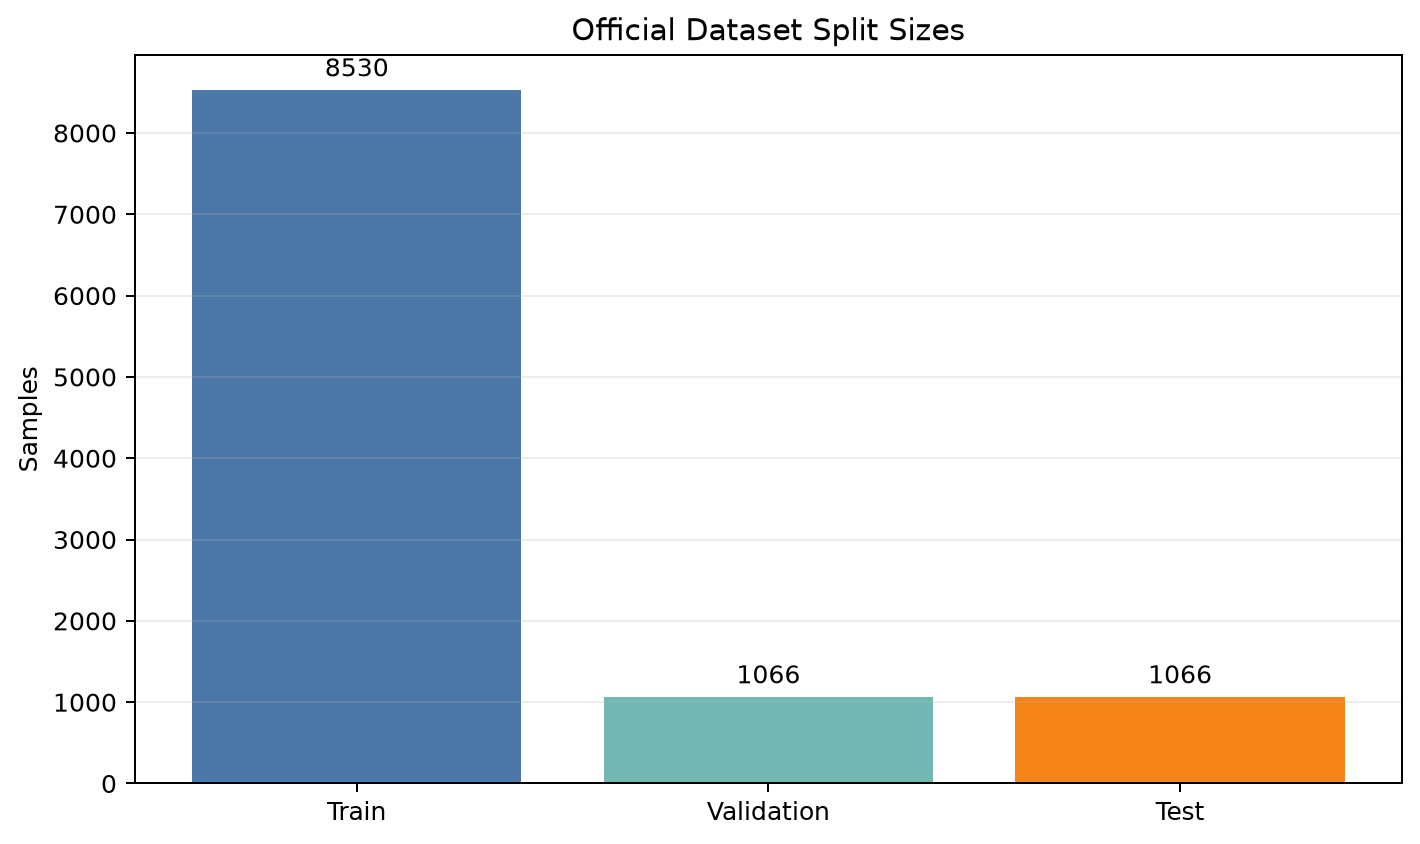

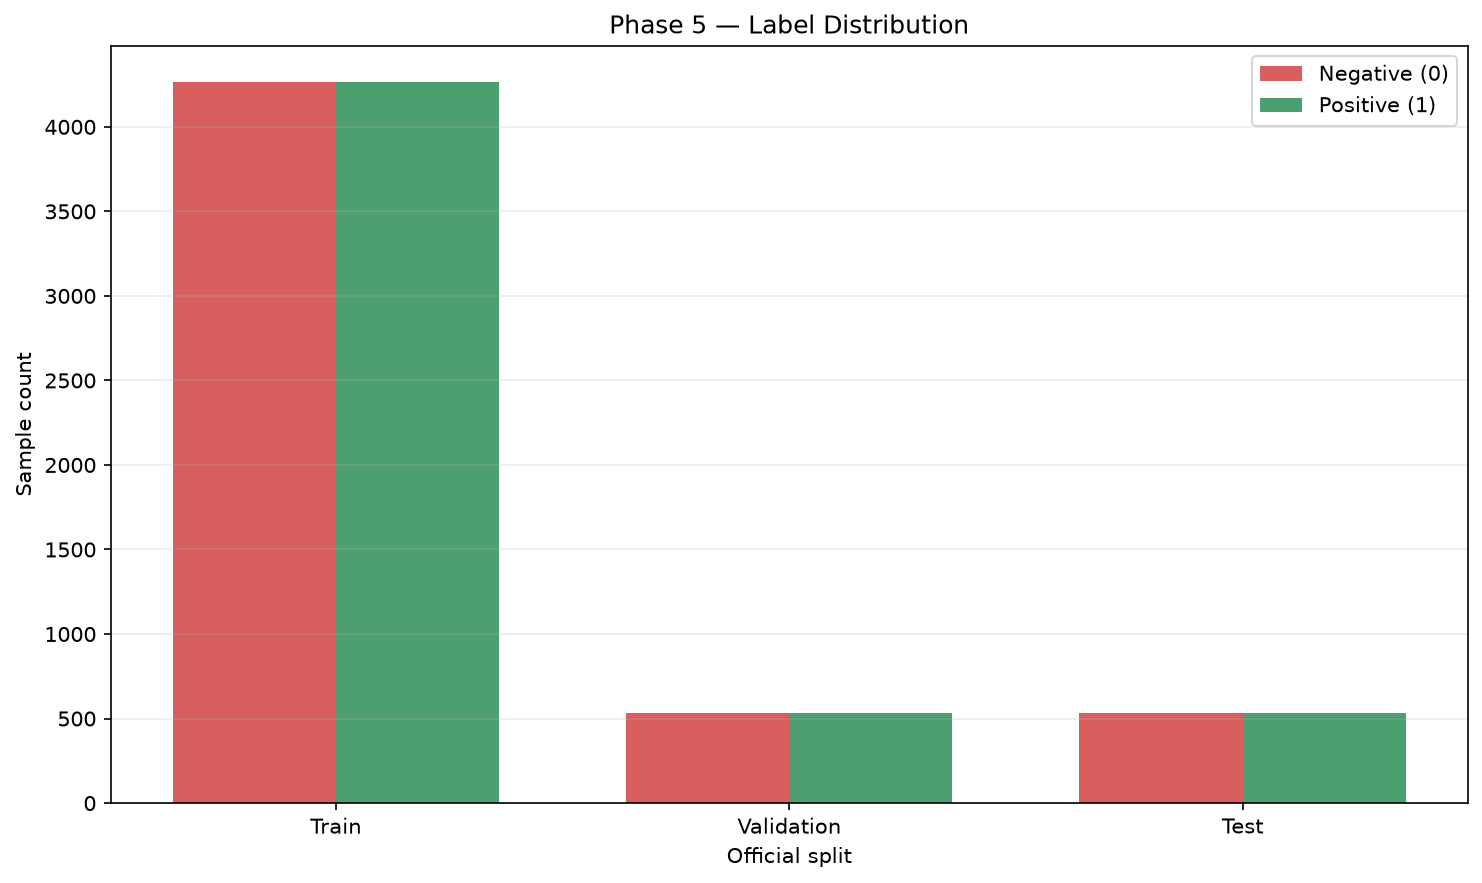

**Observation:** 8,530 / 1,066 / 1,066 samples; every split is exactly balanced.  
**Interpretation:** no missing text, duplicate or cross-split overlap was found.  
**Decision:** preserve the official splits without weighting or resampling.

### Text and token length

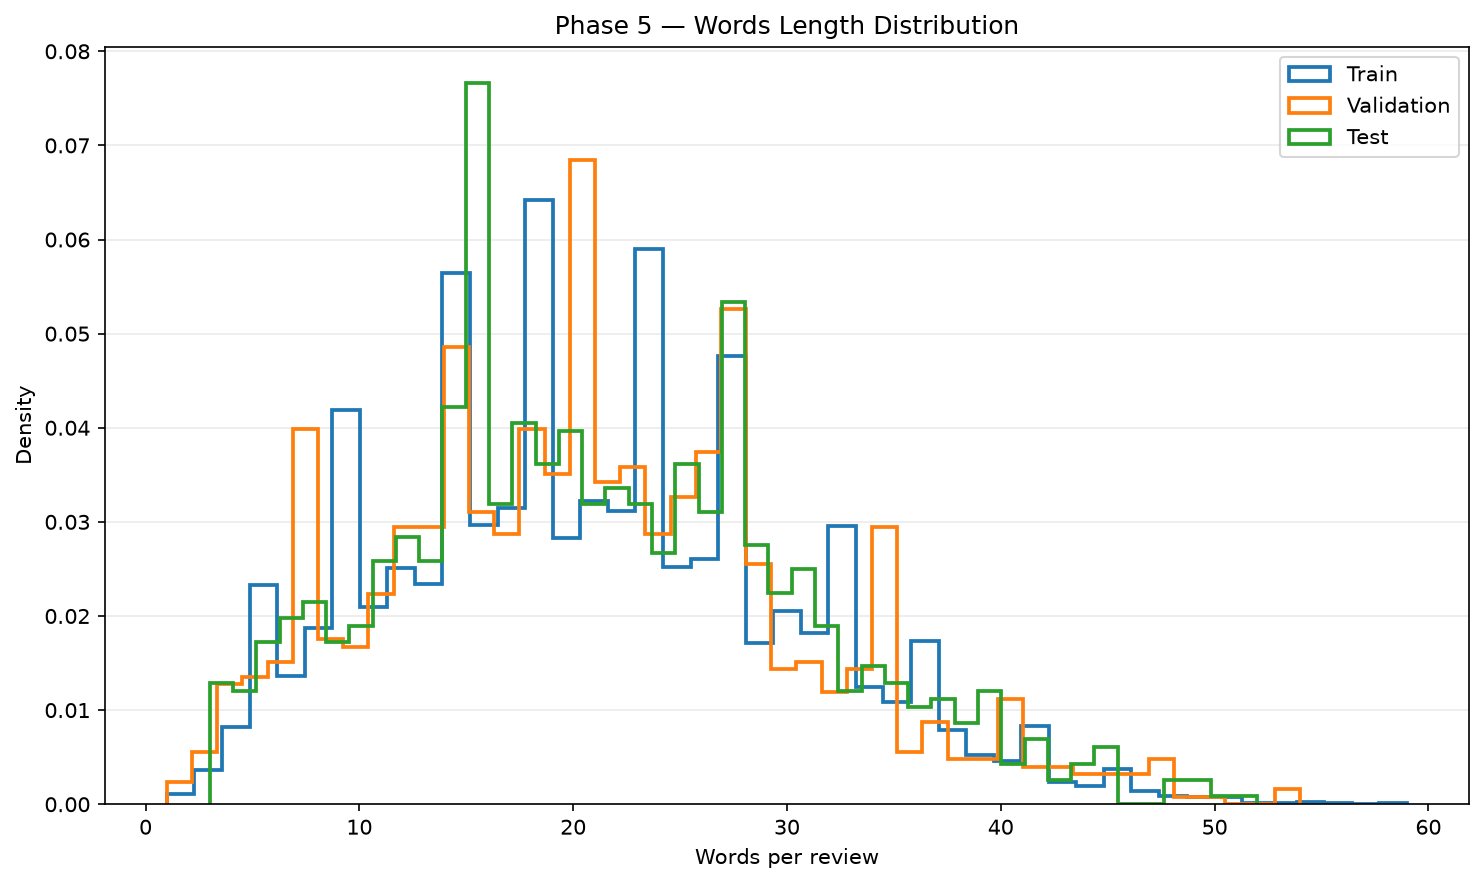

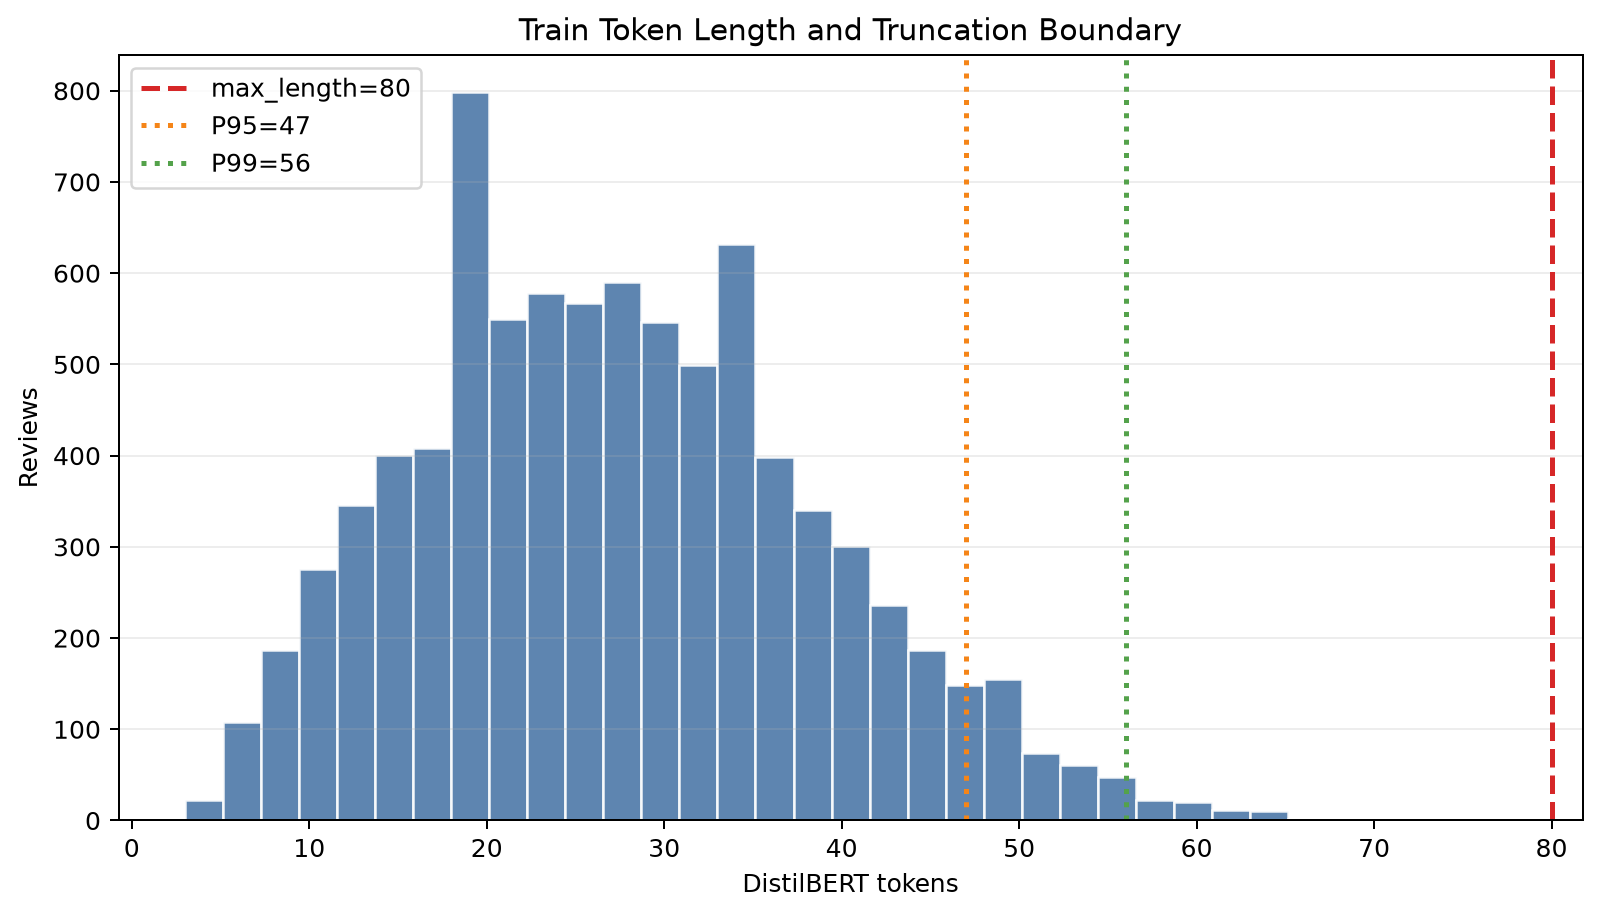

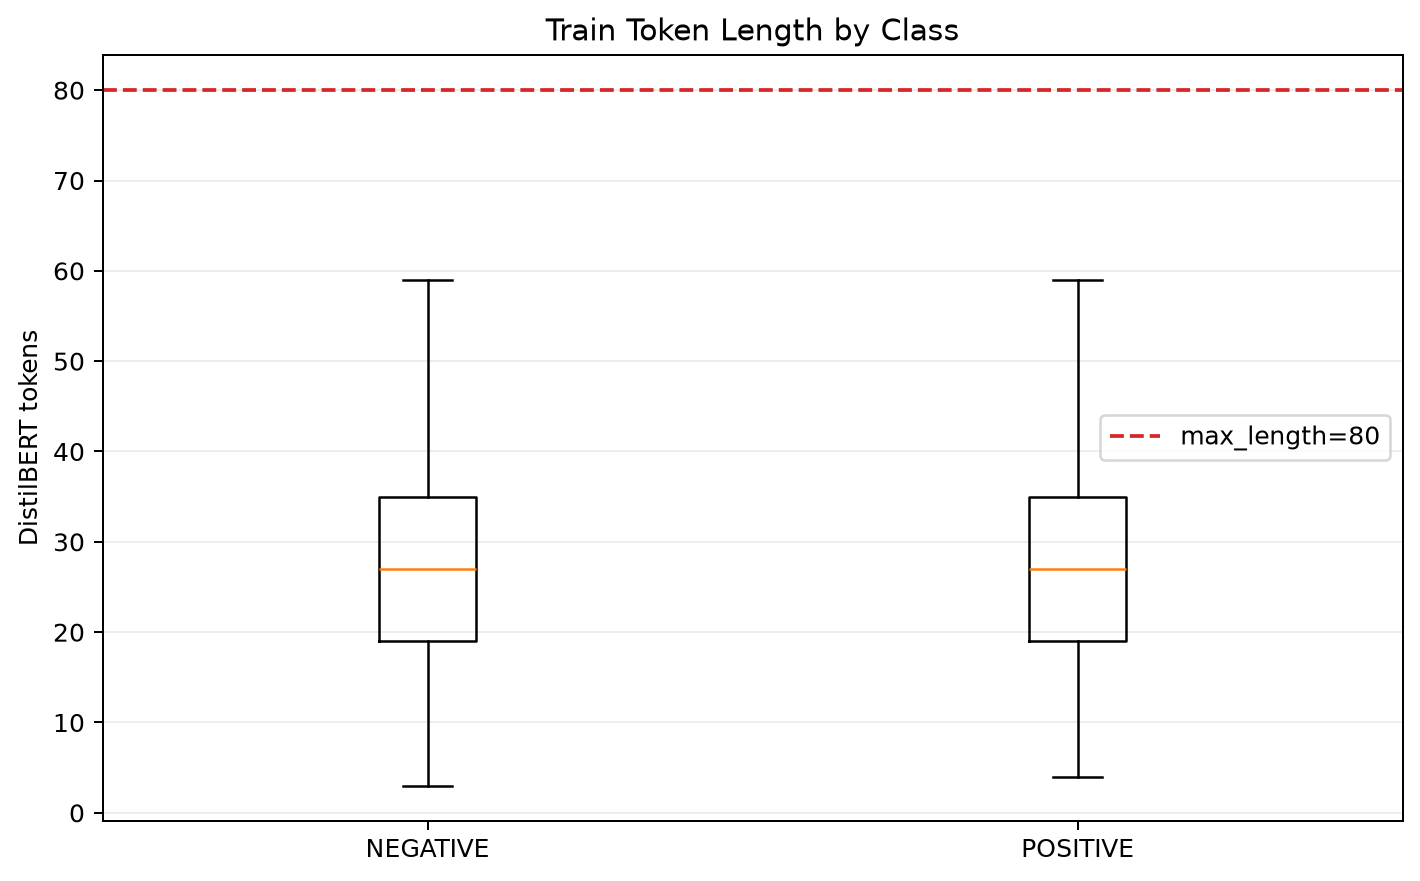

,P50,P75,P90,P95,P99,maximum,samples_over_max_length,percentage_over_max_length
0,27.0,35.0,43.0,47.0,56.0,78,0,0.0


**Observe:** both classes have similar token-length ranges and the observed Train maximum is below 80.  
**Explain:** P95/P99 cover nearly all reviews and no observed Train review exceeds 80 tokens.  
**Decision:** retain `MAX_TOKEN_LENGTH=80`; no methodology change is needed.

**Conclusion:** MAX_TOKEN_LENGTH=80 is retained; observed truncation rate is 0%.

In [6]:
# Phase 5: EDA and Sanity Checks
import pandas as pd
from IPython.display import Image, Markdown, display
from processing_own_phase.phase_05_dataset_eda import (
    build_eda_summary,
    create_eda_figures,
    save_eda_summary,
    save_token_length_statistics,
)
from processing_own_phase.phase_06_preprocessing import get_tokenizer
from processing_own_phase.config import MAX_TOKEN_LENGTH
from processing_own_phase.presentation_quality import phase_5_presentation

tokenizer = get_tokenizer()
eda_summary = build_eda_summary(dataset, tokenizer, MAX_TOKEN_LENGTH)
assert eda_summary['all_pass'], "Phase 5 EDA sanity checks failed"
recommendation = eda_summary['token_length_recommendation']
assert MAX_TOKEN_LENGTH >= recommendation['max']
eda_summary['selected_max_length'] = MAX_TOKEN_LENGTH
eda_summary['max_length_justification'] = (
    f"P95={recommendation['p95']:.0f}, P99={recommendation['p99']:.0f}, "
    f"observed max={recommendation['max']:.0f}; selected {MAX_TOKEN_LENGTH} "
    "is the smallest convenient rounded value above the observed maximum."
)
eda_summary['eda_conclusion'] = {
    'balanced': all(abs(row['positive_pct'] - 50.0) < 1e-12 for row in eda_summary['label_distribution'].values()),
    'missing_text_found': any(sum(row.values()) > 0 for row in eda_summary['text_quality'].values()),
    'duplicate_or_overlap_found': any(eda_summary['within_split_duplicates'].values()) or any(eda_summary['cross_split_overlap'].values()),
    'truncation_risk_at_selected_length': any(row['samples_over_max_length'] > 0 for row in eda_summary['truncation_impact'].values()),
    'phase_06_decision': f'Tokenize with truncation=True, padding=False, max_length={MAX_TOKEN_LENGTH}; use dynamic batch padding.',
}
figure_paths = create_eda_figures(dataset, tokenizer, MAX_TOKEN_LENGTH)
phase_5_visuals = phase_5_presentation(dataset, tokenizer, MAX_TOKEN_LENGTH)
eda_summary_path = save_eda_summary(eda_summary)
token_stats_path = save_token_length_statistics({
    'all_split_length_statistics': eda_summary['all_split_length_statistics'],
    'token_length_recommendation': recommendation,
    'selected_max_length': MAX_TOKEN_LENGTH,
    'truncation_impact': eda_summary['truncation_impact'],
    'justification': eda_summary['max_length_justification'],
})

display(Markdown('### Dataset size and class balance'))
label_rows = [{'split': split, **values} for split, values in eda_summary['label_distribution'].items()]
display(Image(filename=phase_5_visuals['figures']['split_sizes']))
display(Image(filename=figure_paths['label_distribution']))
display(Markdown('**Observation:** 8,530 / 1,066 / 1,066 samples; every split is exactly balanced.  \n**Interpretation:** no missing text, duplicate or cross-split overlap was found.  \n**Decision:** preserve the official splits without weighting or resampling.'))

display(Markdown('### Text and token length'))
display(Image(filename=figure_paths['word_length_distribution']))
display(Image(filename=phase_5_visuals['figures']['token_histogram']))
display(Image(filename=phase_5_visuals['figures']['token_by_class']))
display(pd.DataFrame([phase_5_visuals['token_percentiles']]))
display(Markdown('**Observe:** both classes have similar token-length ranges and the observed Train maximum is below 80.  \n**Explain:** P95/P99 cover nearly all reviews and no observed Train review exceeds 80 tokens.  \n**Decision:** retain `MAX_TOKEN_LENGTH=80`; no methodology change is needed.'))

display(Markdown('**Conclusion:** MAX_TOKEN_LENGTH=80 is retained; observed truncation rate is 0%.'))

# Phase 6: Tokenizer and Preprocessing

In [7]:
# Phase 6: Tokenizer and Preprocessing
from processing_own_phase.phase_06_preprocessing import (
    get_tokenizer,
    tokenize_dataset,
    check_tokenized_sample,
    decode_sanity_check,
    verify_preprocessing,
    verify_dynamic_padding,
    save_preprocessing_summary,
)
from processing_own_phase.presentation_quality import phase_6_examples

tokenizer = get_tokenizer()
tokenized_dataset = tokenize_dataset(dataset, tokenizer)
sample_check = check_tokenized_sample(tokenized_dataset, "train", 0)
decode_checks = decode_sanity_check(tokenized_dataset, tokenizer, dataset, "train", 3)
assert sample_check['all_pass']
assert all(check['pass'] for check in decode_checks)
preprocessing_summary = verify_preprocessing(dataset, tokenized_dataset, tokenizer)
dynamic_padding = verify_dynamic_padding(tokenized_dataset, tokenizer)
assert preprocessing_summary['all_pass']
assert dynamic_padding['all_pass']
preprocessing_summary['dynamic_padding'] = dynamic_padding
preprocessing_summary_path = save_preprocessing_summary(preprocessing_summary)
phase_6_demo = phase_6_examples(dataset, tokenized_dataset, tokenizer)
display(Markdown('### Preprocessing flow'))
display(Markdown(f'`{phase_6_demo["flow"]}`'))
example_rows = [{**row, 'tokens': row['tokens'][:12], 'input_ids': row['input_ids'][:12], 'attention_mask': row['attention_mask'][:12]} for row in phase_6_demo['examples']]
display(pd.DataFrame(example_rows))
display(Markdown('**Interpretation:** text becomes numerical input IDs and an attention mask before DistilBERT processing. Dynamic padding pads only to the longest sequence in each batch.  \n**Conclusion:** preprocessing and dynamic padding: **PASS**.'))

### Preprocessing flow

`Raw text → tokens → input_ids + attention_mask → dynamic padding → DistilBERT`

,sample_index,text,tokens,input_ids,attention_mask,token_count,truncated
0,0,the rock is destined to be the 21st century's ...,"[[CLS], the, rock, is, destined, to, be, the, ...","[101, 1996, 2600, 2003, 16036, 2000, 2022, 199...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",47,False
1,4852,obvious,"[[CLS], obvious, [SEP]]","[101, 5793, 102]","[1, 1, 1]",3,False


**Interpretation:** text becomes numerical input IDs and an attention mask before DistilBERT processing. Dynamic padding pads only to the longest sequence in each batch.  
**Conclusion:** preprocessing and dynamic padding: **PASS**.

## Phase 7 — Model Construction and Sanity Check

Construct the generic pretrained DistilBERT binary classifier and verify its Phase 6 input contract using one deterministic **Train-only** batch. This phase performs no training, validation, Test access, optimizer/scheduler creation, or model-checkpoint saving.

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


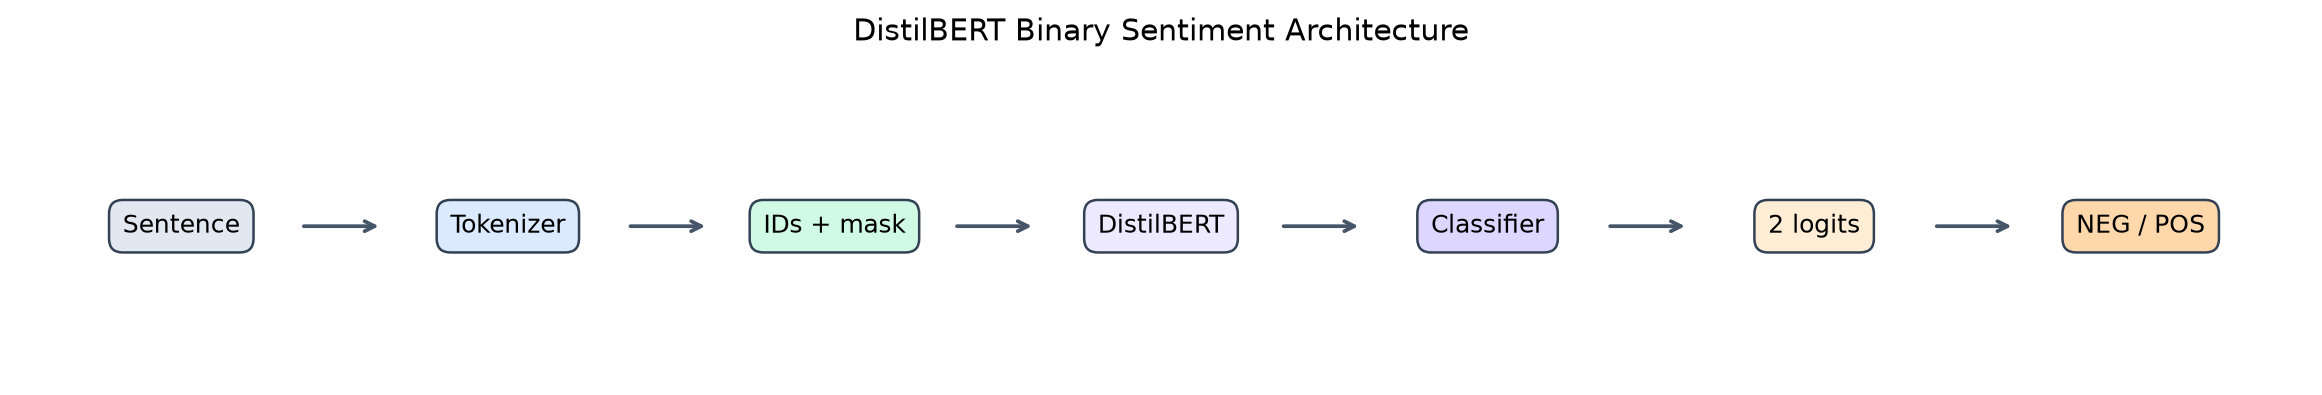

The pretrained DistilBERT backbone supplies contextual language representations; the classification head maps them to two sentiment logits. Fine-tuning adapts both components to Rotten Tomatoes.

,Model,Labels,Total parameters,Trainable parameters,Input shape,Logits shape,Forward pass
0,DistilBertForSequenceClassification,2,66955010,66955010,"[2, 47]","[2, 2]",PASS


**Conclusion:** the binary DistilBERT head accepts the Phase 6 batch and returns finite [B, 2] logits: **PASS**.

In [8]:
# Phase 7: Model Construction + Train-only Forward Sanity Check
from processing_own_phase.phase_06_preprocessing import get_data_collator
from processing_own_phase.phase_07_model_construction import (
    build_model, verify_model_construction, save_model_verification,
)
from processing_own_phase.presentation_quality import phase_7_architecture_figure

model = build_model()
phase_07_verification = verify_model_construction(
    model, tokenizer, tokenized_dataset, get_data_collator(tokenizer)
)
assert phase_07_verification['status'] == 'PASS', phase_07_verification
phase_07_artifact_path = save_model_verification(phase_07_verification)
phase_07_architecture_path = phase_7_architecture_figure()
display(Image(filename=phase_07_architecture_path))
display(Markdown('The pretrained DistilBERT backbone supplies contextual language representations; the classification head maps them to two sentiment logits. Fine-tuning adapts both components to Rotten Tomatoes.'))

display(pd.DataFrame([{
    'Model': phase_07_verification['model_class'],
    'Labels': phase_07_verification['num_labels'],
    'Total parameters': phase_07_verification['total_parameters'],
    'Trainable parameters': phase_07_verification['trainable_parameters'],
    'Input shape': phase_07_verification['batch_tensor_shapes']['input_ids'],
    'Logits shape': phase_07_verification['logits_shape'],
    'Forward pass': phase_07_verification['status'],
}]))
display(Markdown('**Conclusion:** the binary DistilBERT head accepts the Phase 6 batch and returns finite [B, 2] logits: **PASS**.'))

## Phase 8 — Metrics and Training Configuration

Verify the binary Accuracy, Precision, Recall and F1 contract; construct the approved baseline `TrainingArguments`; and verify the Validation-only checkpoint ranking policy. This phase creates no `Trainer`, performs no training, and does not access Test.

In [9]:
# Phase 8: Metrics + Training Configuration (configuration only)
from processing_own_phase.phase_08_metrics_training_configuration import (
    create_training_arguments,
    verify_phase_08,
    save_phase_08_verification,
)

training_args = create_training_arguments()
phase_08_verification = verify_phase_08(training_args)
assert phase_08_verification['status'] == 'PASS', phase_08_verification
phase_08_artifact_path = save_phase_08_verification(phase_08_verification)

effective = phase_08_verification['effective_training_arguments']
display(pd.DataFrame([
    {'Parameter': 'Model', 'Value': 'DistilBERT'},
    {'Parameter': 'Max Length', 'Value': 80},
    {'Parameter': 'Epochs', 'Value': effective['num_train_epochs']},
    {'Parameter': 'Learning Rate', 'Value': effective['learning_rate']},
    {'Parameter': 'Train / Eval Batch', 'Value': f"{effective['per_device_train_batch_size']} / {effective['per_device_eval_batch_size']}"},
    {'Parameter': 'Optimizer', 'Value': str(training_args.optim)},
    {'Parameter': 'Selection Metric', 'Value': 'Validation Loss'},
    {'Parameter': 'Seed', 'Value': effective['seed']},
]))
display(pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'], 'Purpose': ['Overall correctness', 'Positive prediction quality', 'Positive-class coverage', 'Precision–Recall balance']}))
display(Markdown('**Decision:** model selection uses Validation loss only; Test does not participate in training or checkpoint selection.'))

,Parameter,Value
0,Model,DistilBERT
1,Max Length,80
2,Epochs,3.0
3,Learning Rate,0.00002
4,Train / Eval Batch,16 / 32
5,Optimizer,OptimizerNames.ADAMW_TORCH_FUSED
6,Selection Metric,Validation Loss
7,Seed,42


,Metric,Purpose
0,Accuracy,Overall correctness
1,Precision,Positive prediction quality
2,Recall,Positive-class coverage
3,F1,Precision–Recall balance


**Decision:** model selection uses Validation loss only; Test does not participate in training or checkpoint selection.

## Phase 9 — Fine-Tuning

Run the mandatory debug gate and fresh three-epoch Train/Validation baseline once. On later Run All executions, the guard validates and reloads the selected checkpoint from complete Phase 9 artifacts without retraining. Test remains isolated.

In [10]:
# Phase 9: guarded fine-tuning call + artifact presentation
from processing_own_phase.phase_09_fine_tuning import (
    run_or_load_phase_09, load_phase_09_report,
)
from processing_own_phase.phase_10_learning_curves import load_phase_09_artifacts, build_epoch_records

model, phase_09_manifest = run_or_load_phase_09(
    debug_model=model,
    train_dataset=tokenized_dataset['train'],
    validation_dataset=tokenized_dataset['validation'],
    data_collator=get_data_collator(tokenizer),
    tokenizer=tokenizer,
)
phase_09_report = load_phase_09_report()
assert phase_09_report['manifest']['status'] == 'PASS'
assert phase_09_report['debug']['status'] == 'PASS'
assert phase_09_report['manifest']['test_accessed'] is False

phase_09_epochs = build_epoch_records(load_phase_09_artifacts())
display(pd.DataFrame(phase_09_epochs).rename(columns={'epoch': 'Epoch', 'train_loss': 'Train Loss', 'validation_loss': 'Val Loss', 'validation_accuracy': 'Val Accuracy', 'validation_f1': 'Val F1'}).drop(columns=['step']))
selected_09 = phase_09_report['selected_checkpoint']
display(pd.DataFrame([{
    'Selected epoch': selected_09['epoch'],
    'Selected checkpoint': 'checkpoint-1068',
    'Selection rule': 'Lowest Validation Loss',
    'Training artifact loaded': 'PASS',
    'Checkpoint available': 'PASS',
}]))
display(Markdown('**Conclusion:** epoch 2 has the lowest Validation loss and is locked as checkpoint-1068.'))

,Epoch,Train Loss,Val Loss,Val Accuracy,Val F1
0,1.0,0.421368,0.415231,0.818949,0.837951
1,2.0,0.241609,0.390465,0.856473,0.857939
2,3.0,0.147964,0.492693,0.854597,0.857668


,Selected epoch,Selected checkpoint,Selection rule,Training artifact loaded,Checkpoint available
0,2.0,checkpoint-1068,Lowest Validation Loss,PASS,PASS


**Conclusion:** epoch 2 has the lowest Validation loss and is locked as checkpoint-1068.

## Phase 10 — Learning Curves and Training Analysis

Read the verified Phase 9 artifacts to visualize the three-epoch training trajectory and analyze generalization. Phase 10 does not load/evaluate a model or dataset, retrain, access Test, or change the selected checkpoint.

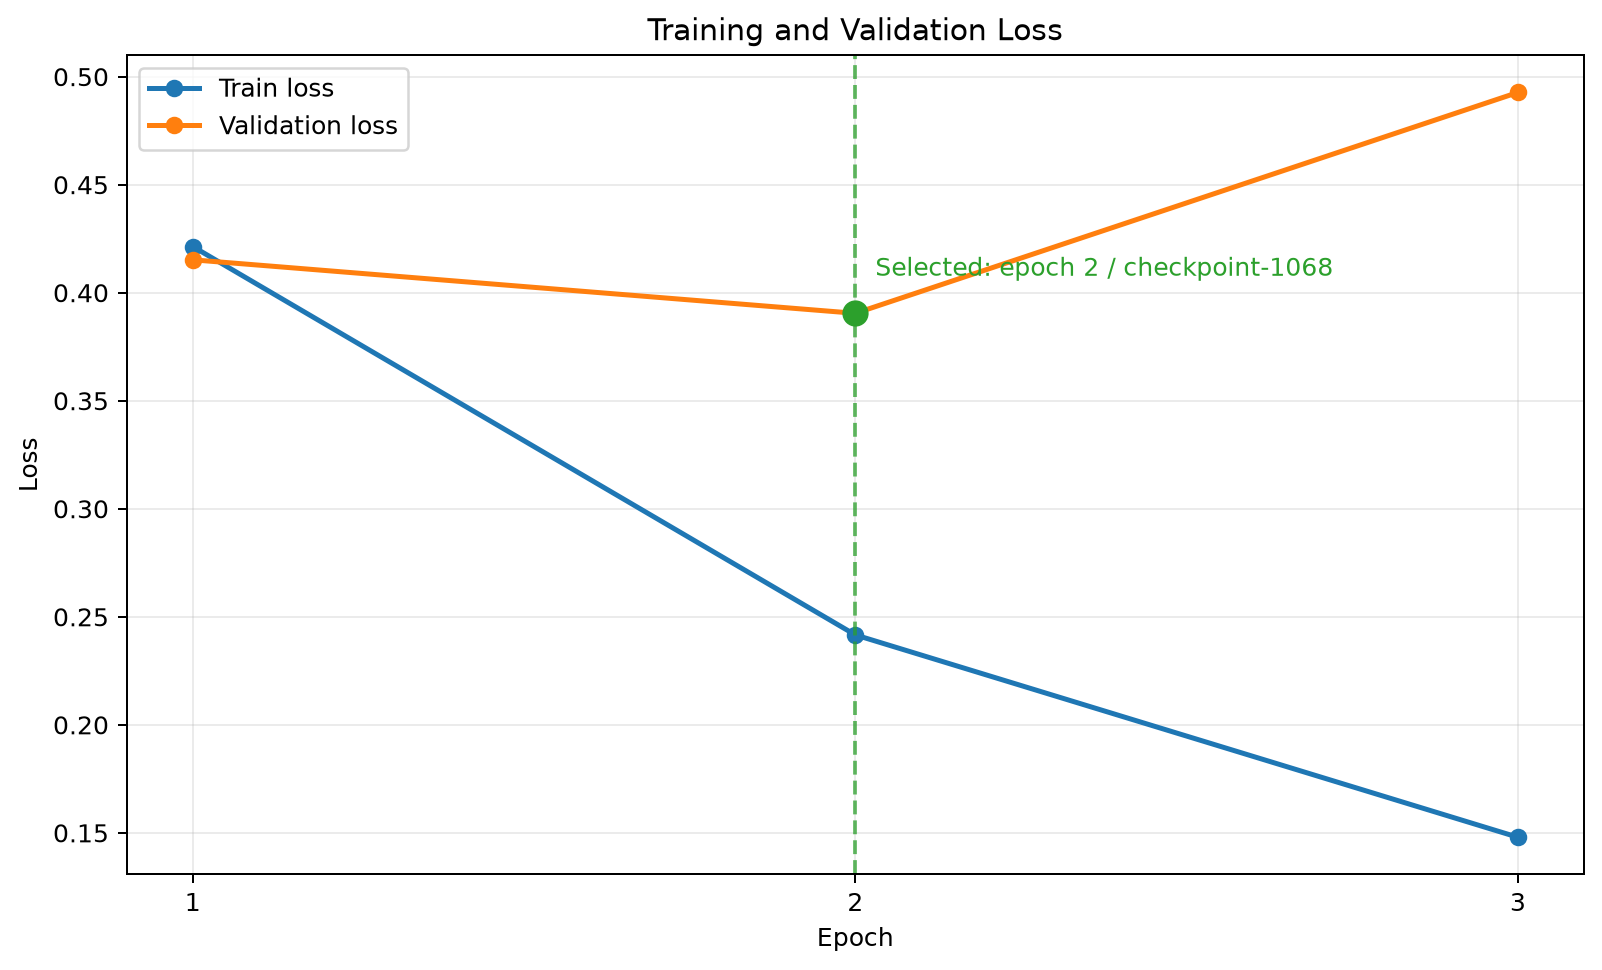

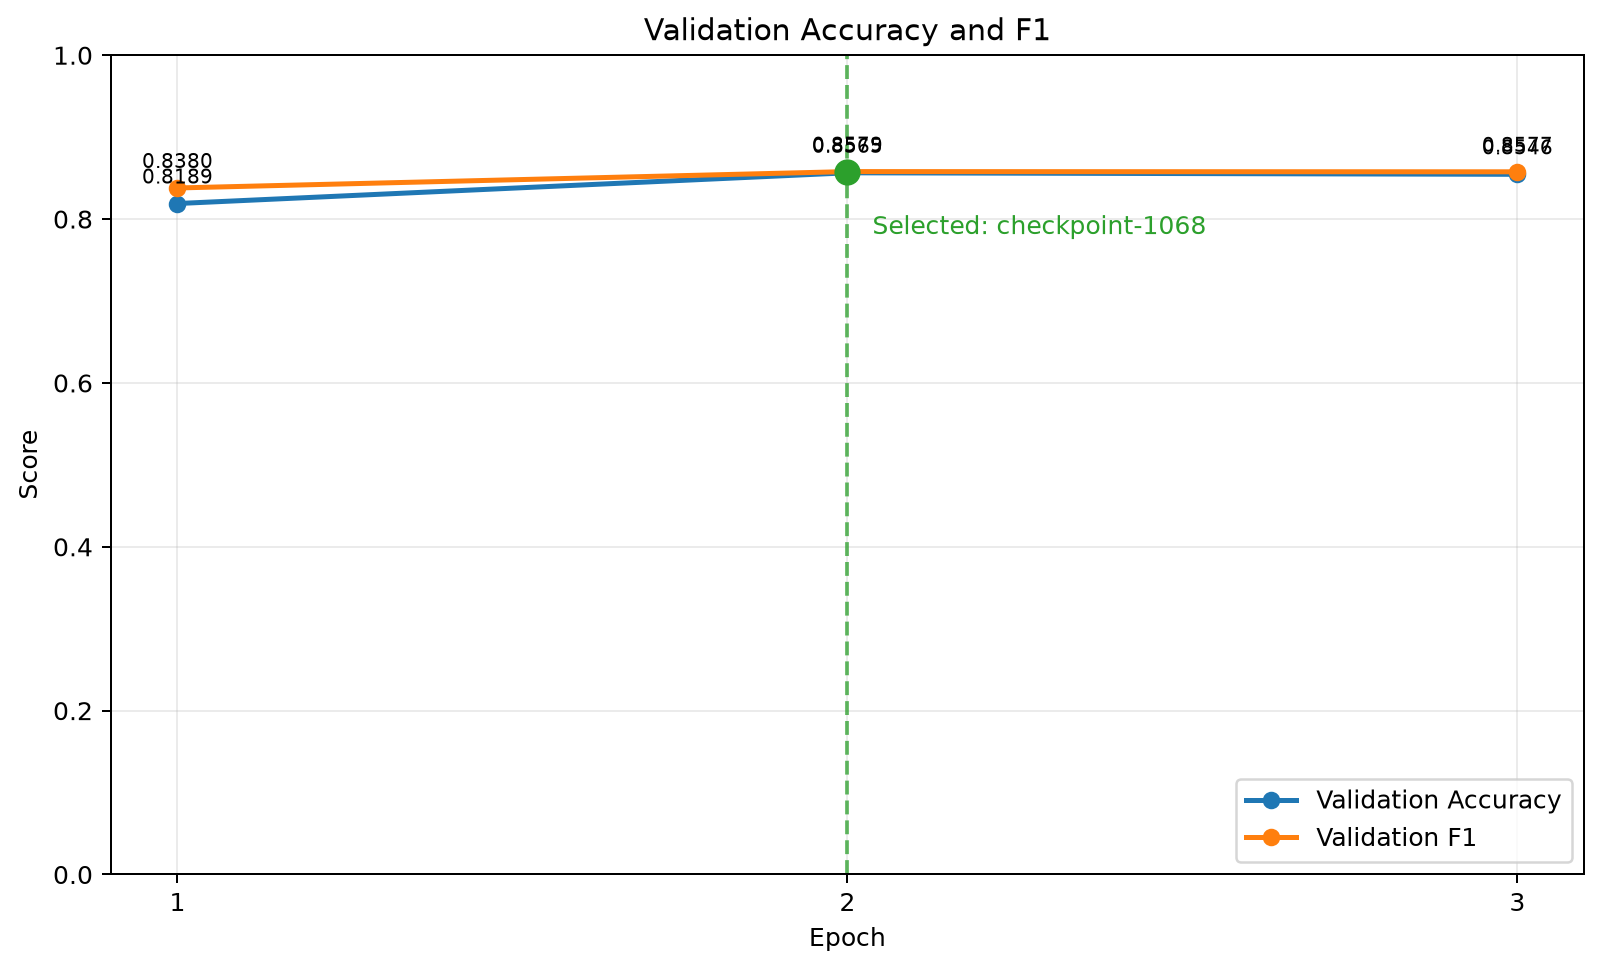

**Epoch 1 → 2:** Validation loss decreases and Validation F1 improves.  
**Epoch 2 → 3:** Train loss continues decreasing while Validation loss increases; generalization begins to worsen.  
**Conclusion:** epoch 2 provides the best observed generalization and remains the selected checkpoint.

In [11]:
# Phase 10: artifact-only learning curves and analysis
from processing_own_phase.phase_10_learning_curves import analyze_learning_curves

phase_10_analysis = analyze_learning_curves()
assert phase_10_analysis['status'] == 'PASS', phase_10_analysis
assert phase_10_analysis['test_accessed'] is False

display(Image(filename=phase_10_analysis['figures']['loss_curves']['path']))
display(Image(filename=phase_10_analysis['figures']['validation_metrics']['path']))
display(Markdown('**Epoch 1 → 2:** Validation loss decreases and Validation F1 improves.  \n**Epoch 2 → 3:** Train loss continues decreasing while Validation loss increases; generalization begins to worsen.  \n**Conclusion:** epoch 2 provides the best observed generalization and remains the selected checkpoint.'))

## Phase 11 — Validation Verification and Final Test Evaluation

Reload the fixed Phase 9 epoch-2 checkpoint, reproduce its Validation metrics within the approved tolerances, and only then perform the single final Test evaluation. Later Run All executions load the frozen Phase 11 artifacts and do not evaluate Test again.

### A. Selected Model

,Best checkpoint,Best epoch,Selection
0,checkpoint-1068,2,Lowest Validation Loss


### B. Verification

,Check,Status
0,Checkpoint unchanged,PASS
1,Validation reproduced,PASS
2,Test used for model selection,NO
3,Final Test evaluation count,1


### C. Final Metrics

,metric,Validation,Final Test
0,loss,0.390465,0.448512
1,accuracy,0.856473,0.845216
2,precision,0.849265,0.845865
3,recall,0.866792,0.844278
4,f1,0.857939,0.845070


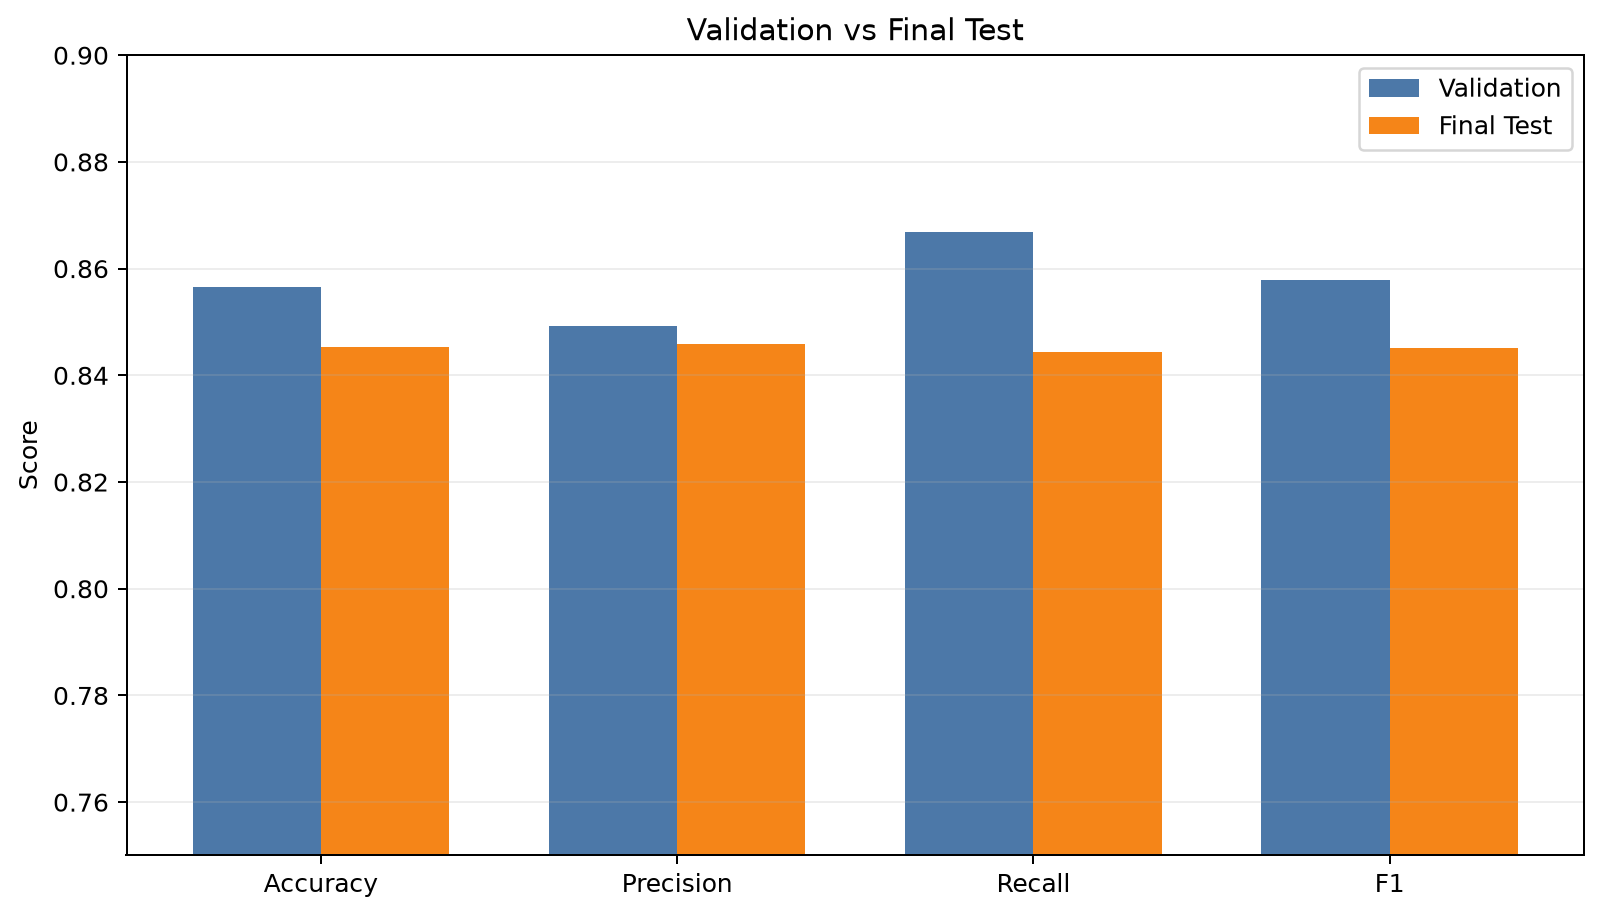

,Accuracy gap (pp),F1 gap (pp)
0,1.125704,1.28683


**Interpretation:** Test Accuracy is 1.13 percentage points and Test F1 is 1.29 points below Validation. This is a modest generalization drop; the locked checkpoint remains unchanged and Test is not reused for tuning.

In [12]:
# Phase 11: guarded Validation verification + one-time final Test evaluation
from processing_own_phase.phase_11_final_evaluation import (
    run_or_load_phase_11, load_phase_11_report,
)
from processing_own_phase.presentation_quality import artifact_presentation

phase_11_run = run_or_load_phase_11(
    validation_dataset=tokenized_dataset['validation'],
    data_collator=get_data_collator(tokenizer),
    tokenizer=tokenizer,
    test_data_provider=lambda: (tokenized_dataset['test'], dataset['test']),
)
phase_11_report = load_phase_11_report()
presentation_report = artifact_presentation()
assert phase_11_report['checkpoint']['status'] == 'PASS'
assert phase_11_report['validation']['status'] == 'PASS'
assert phase_11_report['test']['status'] == 'PASS'
assert phase_11_report['manifest']['status'] == 'FINAL_TEST_COMPLETE'
assert phase_11_report['manifest']['test_evaluation_count'] == 1
assert phase_11_report['manifest']['test_used_for_selection'] is False
assert phase_11_report['manifest']['phase_12_started'] is False

display(Markdown('### A. Selected Model'))
display(pd.DataFrame([{'Best checkpoint': 'checkpoint-1068', 'Best epoch': 2, 'Selection': 'Lowest Validation Loss'}]))
display(Markdown('### B. Verification'))
display(pd.DataFrame([
    {'Check': 'Checkpoint unchanged', 'Status': 'PASS'},
    {'Check': 'Validation reproduced', 'Status': phase_11_report['validation']['status']},
    {'Check': 'Test used for model selection', 'Status': 'NO'},
    {'Check': 'Final Test evaluation count', 'Status': phase_11_report['manifest']['test_evaluation_count']},
]))
display(Markdown('### C. Final Metrics'))
comparison_rows = [
    {'metric': metric,
     'Validation': phase_11_report['validation']['metrics'][metric],
     'Final Test': phase_11_report['test']['metrics'][metric]}
    for metric in ('loss', 'accuracy', 'precision', 'recall', 'f1')
]
display(pd.DataFrame(comparison_rows))
display(Image(filename=presentation_report['figures']['validation_vs_test']))
gaps = presentation_report['validation_test_gaps']
display(pd.DataFrame([{'Accuracy gap (pp)': gaps['accuracy_gap_percentage_points'], 'F1 gap (pp)': gaps['f1_gap_percentage_points']}]))
display(Markdown('**Interpretation:** Test Accuracy is 1.13 percentage points and Test F1 is 1.29 points below Validation. This is a modest generalization drop; the locked checkpoint remains unchanged and Test is not reused for tuning.'))

## Phase 12 — Confusion Matrix and Error Analysis

Analyze only the frozen Phase 11 prediction artifact. This section derives the confusion matrix, class-level behavior and deterministic representative errors without loading a model/dataset, reevaluating Test, changing the checkpoint or starting Phase 13.

### Frozen Final-Test confusion matrix

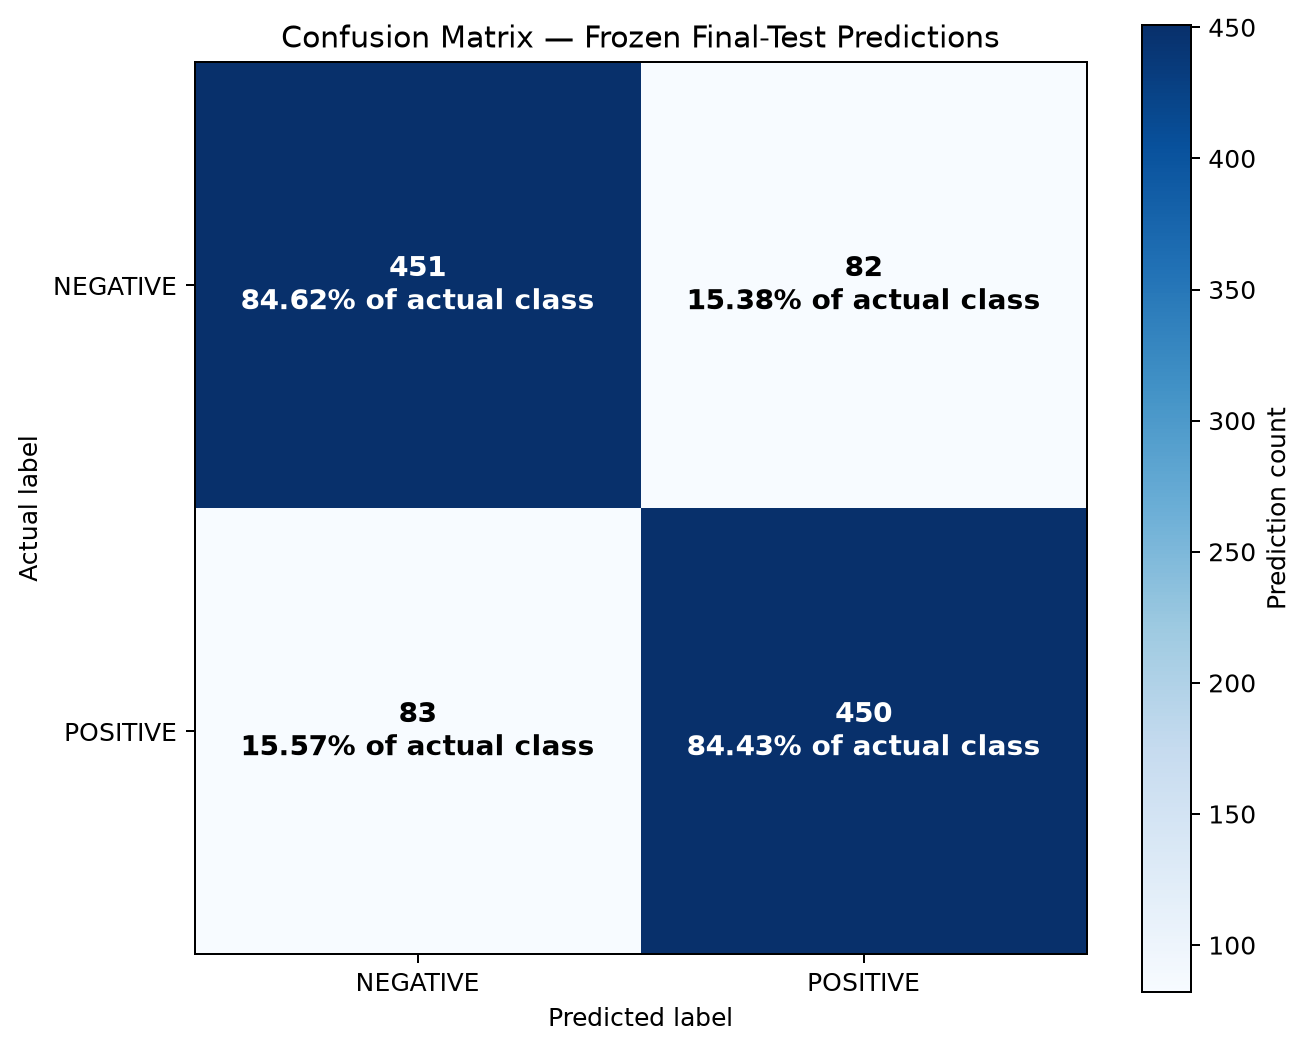

,TN,FP,FN,TP,Correct,Wrong
0,451,82,83,450,901,165


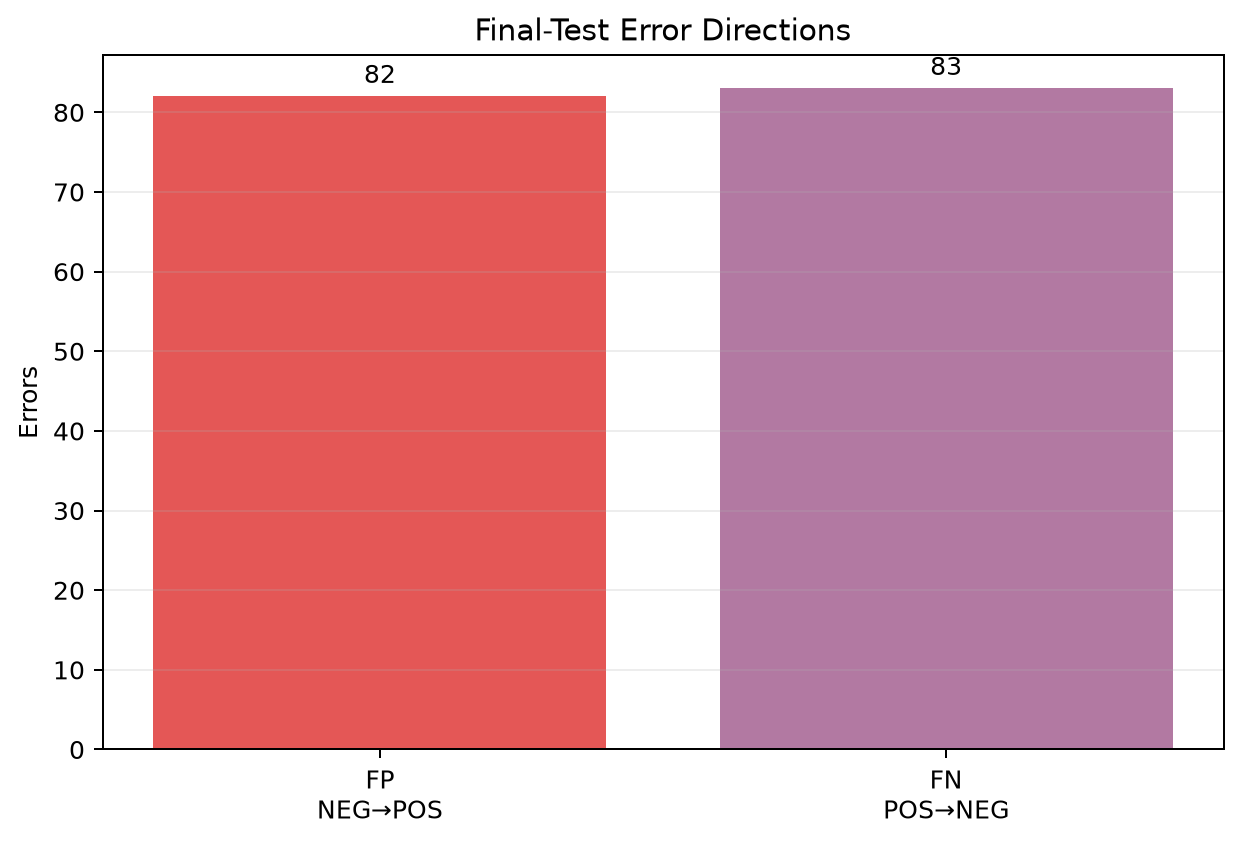

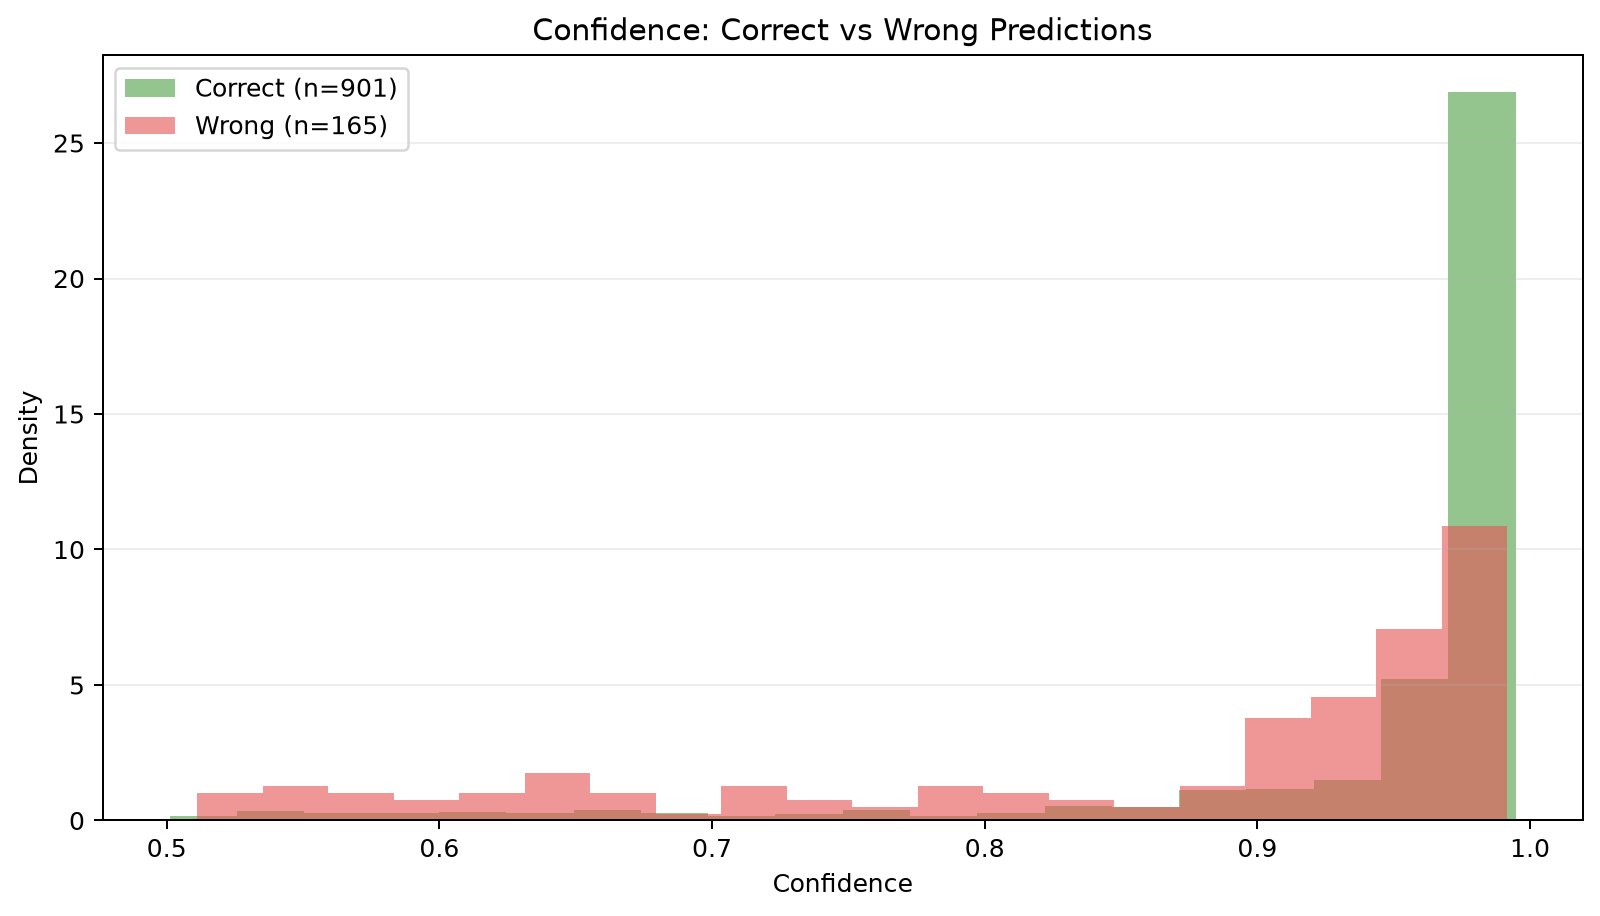

**Observe:** FP and FN counts are nearly symmetric, while some wrong predictions remain highly confident.  
**Explain:** confidence is not a guarantee of correctness, and contrast cues occur more often among errors descriptively.  
**Conclusion:** error review should prioritize high-confidence mistakes and complex/contrastive wording without claiming causation.

,Text,True,Pred,Confidence,Error Type
0,"never again , while nothing special , is pleas...",NEGATIVE,POSITIVE,0.991543,NEGATIVE_TO_POSITIVE
1,entertains not so much because of its music or...,NEGATIVE,POSITIVE,0.990673,NEGATIVE_TO_POSITIVE
2,"a very familiar tale , one that's been told by...",NEGATIVE,POSITIVE,0.990446,NEGATIVE_TO_POSITIVE
3,the wonderful combination of the sweetness and...,POSITIVE,NEGATIVE,0.986777,POSITIVE_TO_NEGATIVE
4,the wild thornberrys movie has all the sibling...,POSITIVE,NEGATIVE,0.985683,POSITIVE_TO_NEGATIVE
5,the modern remake of dumas's story is long on ...,POSITIVE,NEGATIVE,0.985676,POSITIVE_TO_NEGATIVE


**Conclusion:** the model makes 165 errors with nearly symmetric directions (82 FP, 83 FN). Some wrong predictions remain highly confident; contrastive or mixed wording appears among errors, but this is descriptive evidence rather than a causal claim.

In [13]:
# Phase 12: frozen-artifact confusion matrix + deterministic error analysis
from processing_own_phase.phase_12_error_analysis import analyze_phase_12

phase_12_result = analyze_phase_12()
phase_12_confusion = phase_12_result['confusion']
phase_12_errors = phase_12_result['error_samples']
phase_12_analysis = phase_12_result['analysis']
assert phase_12_result['status'] == 'PASS'
assert phase_12_analysis['test_evaluation_count'] == 1
assert phase_12_analysis['model_loaded'] is False
assert phase_12_analysis['dataset_loaded'] is False
assert phase_12_analysis['test_provider_called'] is False
assert phase_12_analysis['test_evaluated'] is False
assert phase_12_analysis['training_performed'] is False
assert phase_12_analysis['checkpoint_changed'] is False
assert phase_12_analysis['phase_13_started'] is False

display(Markdown('### Frozen Final-Test confusion matrix'))
display(Image(filename=phase_12_confusion['figure']['path']))
display(pd.DataFrame([{'TN': phase_12_confusion['counts']['TN'], 'FP': phase_12_confusion['counts']['FP'], 'FN': phase_12_confusion['counts']['FN'], 'TP': phase_12_confusion['counts']['TP'], 'Correct': phase_12_confusion['correct'], 'Wrong': phase_12_confusion['incorrect']}]))
display(Image(filename=presentation_report['figures']['fp_vs_fn']))
display(Image(filename=presentation_report['figures']['confidence_correct_vs_wrong']))
display(Markdown('**Observe:** FP and FN counts are nearly symmetric, while some wrong predictions remain highly confident.  \n**Explain:** confidence is not a guarantee of correctness, and contrast cues occur more often among errors descriptively.  \n**Conclusion:** error review should prioritize high-confidence mistakes and complex/contrastive wording without claiming causation.'))

representative_rows = []
for row in phase_12_errors['representative_errors'][:3] + phase_12_errors['representative_errors'][5:8]:
    representative_rows.append({
        'Text': row['text'], 'True': row['true_label_name'],
        'Pred': row['predicted_label_name'], 'Confidence': row['confidence'],
        'Error Type': row['error_direction'],
    })
display(pd.DataFrame(representative_rows))
display(Markdown('**Conclusion:** the model makes 165 errors with nearly symmetric directions (82 FP, 83 FN). Some wrong predictions remain highly confident; contrastive or mixed wording appears among errors, but this is descriptive evidence rather than a causal claim.'))

## Phase 13 — New-Sentence Inference

Run guarded inference only on newly authored custom sentences using the fixed epoch-2 `checkpoint-1068`. The module verifies the Phase 11 SHA-256 fingerprint, reuses the locked Phase 6 tokenizer contract (`max_length=80`, truncation and dynamic padding), and never loads or reevaluates Test.

### Custom-sentence sentiment predictions

,Type,Sentence,Prediction,Confidence
0,clear positive,I absolutely loved this movie.,POSITIVE,0.976750
1,clear negative,This was painfully boring.,NEGATIVE,0.989125
2,negation,I don't think this movie is bad.,POSITIVE,0.725213
3,contrast,"The acting was excellent, but the story was weak.",NEGATIVE,0.980640
4,mixed sentiment,"It has good moments, although it is far from p...",POSITIVE,0.662595
5,ambiguous / implicit,I am still not sure what the film wanted me to...,NEGATIVE,0.968266


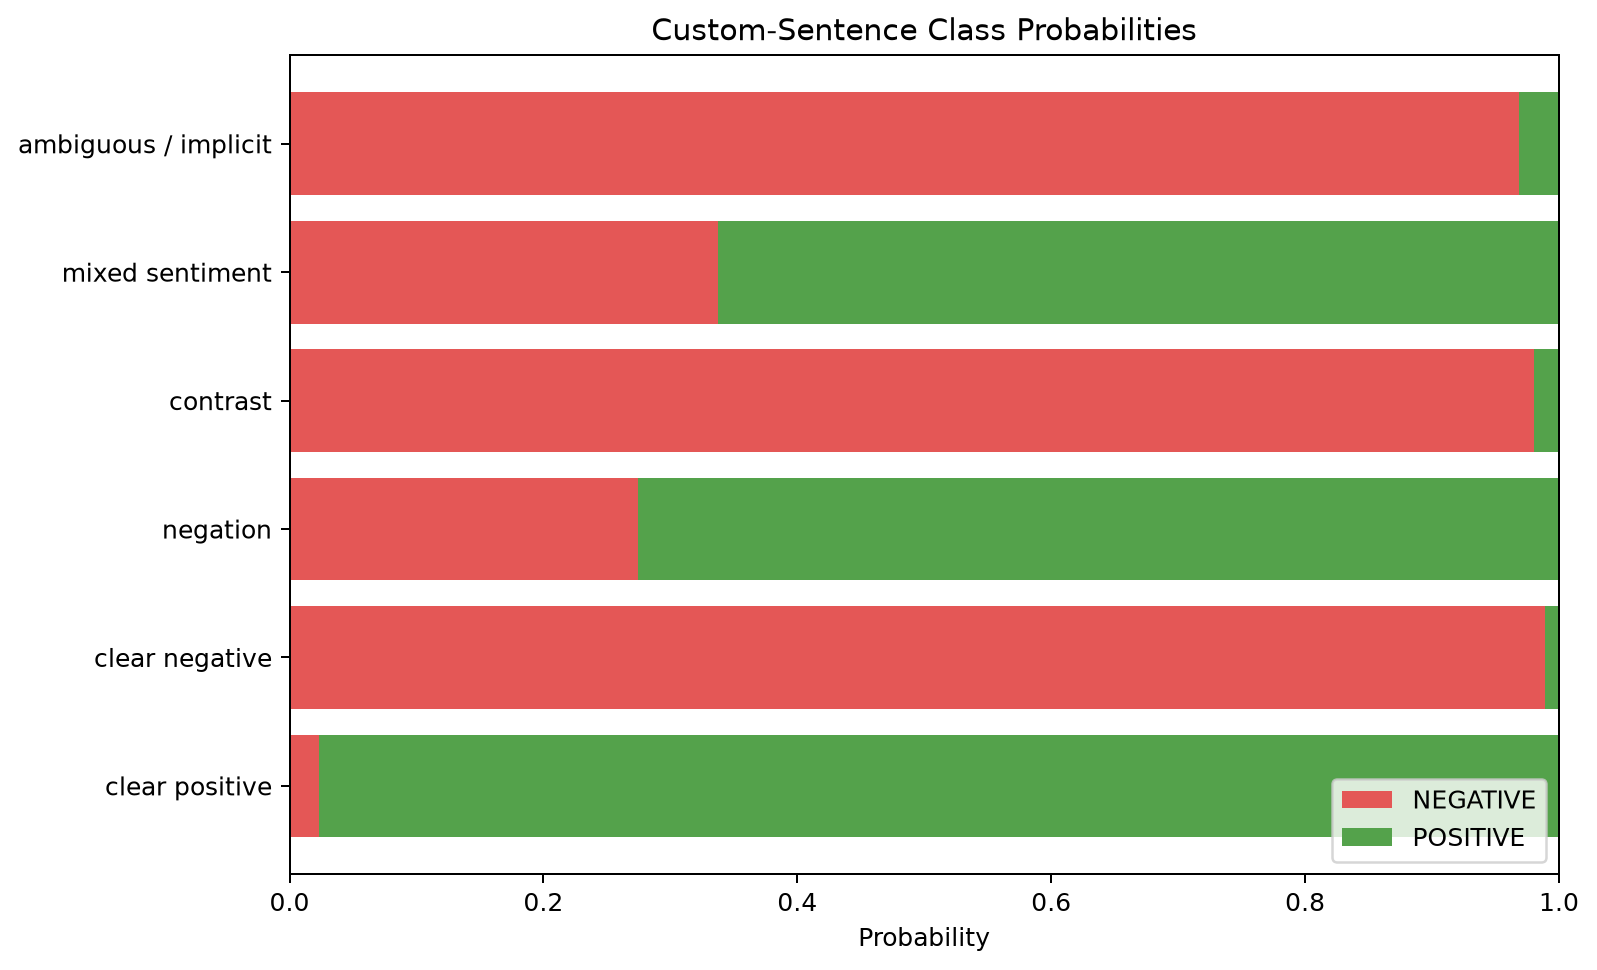

,Uses locked checkpoint,Uses custom text only,Test dataset accessed
0,PASS,PASS,NO


**Conclusion:** probabilities make confidence visible; all examples are custom-authored and the Test dataset remains isolated.

In [14]:
# Phase 13: guarded custom-text inference using the authoritative checkpoint
from processing_own_phase.phase_13_new_sentence_inference import (
    DEFAULT_CUSTOM_SENTENCES, run_or_load_phase_13,
)
from processing_own_phase.presentation_quality import phase_13_presentation_examples, phase_13_probability_figure

phase_13_report = run_or_load_phase_13(DEFAULT_CUSTOM_SENTENCES)
assert phase_13_report['status'] == 'PASS'
assert phase_13_report['checkpoint']['checkpoint_name'] == 'checkpoint-1068'
assert phase_13_report['checkpoint']['epoch'] == 2.0
assert phase_13_report['checkpoint']['step'] == 1068
assert phase_13_report['logits_shape'] == [len(DEFAULT_CUSTOM_SENTENCES), 2]
assert all(phase_13_report['verification']['checks'].values())
assert phase_13_report['training_performed'] is False
assert phase_13_report['test_accessed'] is False
assert phase_13_report['test_evaluated'] is False
assert phase_13_report['test_evaluation_count'] == 1
assert phase_13_report['checkpoint_changed'] is False
assert phase_13_report['phase_14_started'] is False

phase_13_presentation = phase_13_presentation_examples()
phase_13_probability_path = phase_13_probability_figure(phase_13_presentation)
display(Markdown('### Custom-sentence sentiment predictions'))
display(pd.DataFrame([{
    'Type': row['category'], 'Sentence': row['text'], 'Prediction': row['prediction'], 'Confidence': row['confidence'],
} for row in phase_13_presentation['results']]))
display(Image(filename=phase_13_probability_path))
display(pd.DataFrame([{
    'Uses locked checkpoint': 'PASS', 'Uses custom text only': 'PASS', 'Test dataset accessed': 'NO',
}]))
display(Markdown('**Conclusion:** probabilities make confidence visible; all examples are custom-authored and the Test dataset remains isolated.'))

## Phase 14 — Save & Reload

Verify the authoritative epoch-2 `checkpoint-1068`, save a reusable Hugging Face model/tokenizer package once, and prove that its locally reloaded state and predictions are equivalent. Later Run All executions verify/load the package without resaving, training or Test reevaluation.

In [15]:
# Phase 14: guarded package integrity + save/reload equivalence
from processing_own_phase.phase_14_save_reload import run_or_load_phase_14

phase_14_report = run_or_load_phase_14()
assert phase_14_report['status'] == 'PASS'
assert phase_14_report['source_checkpoint']['checkpoint_name'] == 'checkpoint-1068'
assert phase_14_report['source_checkpoint']['epoch'] == 2.0
assert phase_14_report['source_checkpoint']['step'] == 1068
assert phase_14_report['state_dict_equivalence']['status'] == 'PASS'
assert phase_14_report['state_dict_equivalence']['all_tensors_exact_equal'] is True
assert phase_14_report['prediction_equivalence']['status'] == 'PASS'
assert all(phase_14_report['completion_checks'].values())
assert phase_14_report['training_performed'] is False
assert phase_14_report['test_accessed'] is False
assert phase_14_report['test_evaluated'] is False
assert phase_14_report['test_evaluation_count'] == 1
assert phase_14_report['checkpoint_selected_or_changed'] is False
assert phase_14_report['phase_15_started'] is False

display(pd.DataFrame([
    {'Check': 'Model saved', 'Result': 'PASS'},
    {'Check': 'Tokenizer saved', 'Result': 'PASS'},
    {'Check': 'Reload successful', 'Result': 'PASS'},
    {'Check': 'Prediction equivalent', 'Result': phase_14_report['prediction_equivalence']['status']},
    {'Check': 'Maximum probability difference', 'Result': phase_14_report['prediction_equivalence']['probability_max_abs_diff']},
]))
comparison_14 = phase_14_report['prediction_equivalence']['predictions'][:3]
display(pd.DataFrame([{'Sentence': row['text'], 'Before reload': row['source_label_name'], 'After reload': row['reloaded_label_name'], 'Probability difference': row['probability_max_abs_diff_for_input'], 'Status': 'PASS'} for row in comparison_14]))
display(Markdown('**Conclusion:** the locally reloaded model produces equivalent predictions, confirming that the saved package is reusable.'))

,Check,Result
0,Model saved,PASS
1,Tokenizer saved,PASS
2,Reload successful,PASS
3,Prediction equivalent,PASS
4,Maximum probability difference,0.0


,Sentence,Before reload,After reload,Probability difference,Status
0,"The performances were warm, convincing, and de...",POSITIVE,POSITIVE,0.0,PASS
1,"The story was tedious, predictable, and painfu...",NEGATIVE,NEGATIVE,0.0,PASS
2,It is not a bad movie at all.,POSITIVE,POSITIVE,0.0,PASS


**Conclusion:** the locally reloaded model produces equivalent predictions, confirming that the saved package is reusable.

## Phase 15 — Final Summary

Consolidate the verified Phase 0–14 artifacts into the final Practice 3 conclusion. This section is artifact-only: it does not load a model/dataset, train, infer, evaluate Test, change a checkpoint or resave the Phase 14 package.

### Final Summary

,Item,Result
0,Task,Binary Sentiment Classification
1,Dataset,Rotten Tomatoes
2,Model,DistilBERT
3,Train / Val / Test,"8,530 / 1,066 / 1,066"
4,Max Length,80
5,Best Epoch,2
6,Best Checkpoint,checkpoint-1068
7,Validation Loss,0.390465
8,Validation Accuracy,0.856473
9,Validation F1,0.857939


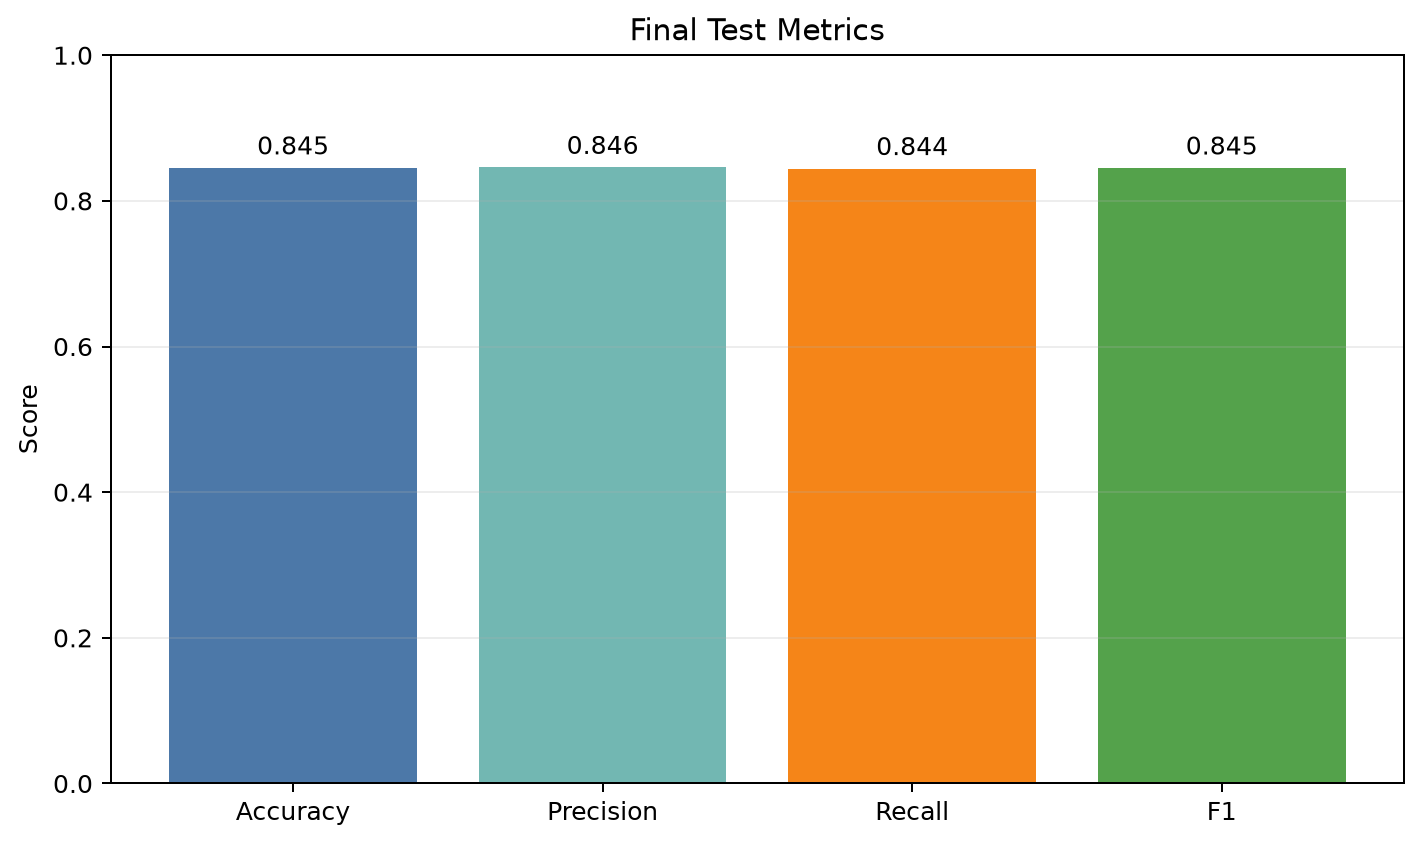

### Final Conclusions
- Epoch 2 gives the best observed generalization; epoch 3 shows overfitting onset.
- Test Accuracy/F1 are modestly below Validation, without post-Test tuning.
- Errors are balanced between FP and FN; complex or contrastive wording remains challenging.
- Evidence covers one three-epoch DistilBERT baseline on Rotten Tomatoes; no broad search or production deployment was performed.

,Practice 3,Methodology,Final Test isolation,Save / Reload
0,COMPLETE,PASS,PASS,PASS


In [16]:
# Phase 15: artifact-only final project summary
from processing_own_phase.phase_15_final_summary import run_or_load_phase_15

phase_15_report = run_or_load_phase_15()
assert phase_15_report['status'] == 'PASS'
assert all(status == 'PASS' for status in phase_15_report['phase_status'].values())
assert all(phase_15_report['verification_checks'].values())
assert phase_15_report['final_model']['selected_checkpoint'] == 'checkpoint-1068'
assert phase_15_report['final_model']['epoch'] == 2.0
assert phase_15_report['final_model']['step'] == 1068
assert phase_15_report['dataset_contract']['split_counts'] == {'train': 8530, 'validation': 1066, 'test': 1066}
assert phase_15_report['test_evaluation_count'] == 1
assert phase_15_report['model_loaded'] is False
assert phase_15_report['dataset_loaded'] is False
assert phase_15_report['training_performed'] is False
assert phase_15_report['inference_performed'] is False
assert phase_15_report['test_accessed'] is False
assert phase_15_report['test_evaluated'] is False
assert phase_15_report['checkpoint_changed'] is False
assert phase_15_report['package_resaved'] is False

display(Markdown('### Final Summary'))
counts_15 = phase_15_report['confusion_matrix']['counts']
summary_rows = [
    ('Task', 'Binary Sentiment Classification'), ('Dataset', 'Rotten Tomatoes'),
    ('Model', 'DistilBERT'), ('Train / Val / Test', '8,530 / 1,066 / 1,066'),
    ('Max Length', 80), ('Best Epoch', 2), ('Best Checkpoint', 'checkpoint-1068'),
    ('Validation Loss', phase_15_report['validation_metrics']['loss']),
    ('Validation Accuracy', phase_15_report['validation_metrics']['accuracy']),
    ('Validation F1', phase_15_report['validation_metrics']['f1']),
    ('Test Loss', phase_15_report['final_test_metrics']['loss']),
    ('Test Accuracy', phase_15_report['final_test_metrics']['accuracy']),
    ('Test F1', phase_15_report['final_test_metrics']['f1']),
    ('Correct / Wrong', f"{phase_15_report['confusion_matrix']['correct']} / {phase_15_report['confusion_matrix']['incorrect']}"),
    ('FP / FN', f"{counts_15['FP']} / {counts_15['FN']}"), ('Save / Reload', 'PASS'),
]
display(pd.DataFrame(summary_rows, columns=['Item', 'Result']))
display(Image(filename=presentation_report['figures']['final_test_metrics']))
display(Markdown('### Final Conclusions\n- Epoch 2 gives the best observed generalization; epoch 3 shows overfitting onset.\n- Test Accuracy/F1 are modestly below Validation, without post-Test tuning.\n- Errors are balanced between FP and FN; complex or contrastive wording remains challenging.\n- Evidence covers one three-epoch DistilBERT baseline on Rotten Tomatoes; no broad search or production deployment was performed.'))
display(pd.DataFrame([{'Practice 3': 'COMPLETE', 'Methodology': 'PASS', 'Final Test isolation': 'PASS', 'Save / Reload': 'PASS'}]))